In [4]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import mytools
from scipy.optimize import curve_fit




In [5]:
data_dir = '/Users/mghrear/data/HPS_data/ensemble/'

In [3]:
fit_ranges = {
    14: (1010, 1045),
    26: (1010, 1045),
    28: (1005, 1045),
    36: (1005, 1045),
    37: (1010, 1050),
    39: (1006, 1045),
    40: (1005, 1045),
    41: (1005, 1045),
    43: (1000, 1045),
    45: (1000, 1045),
    46: (1005, 1045),
    51: (1005, 1045),
    56: (1005, 1045),
    68: (995, 1045),
    73: (1010, 1045),
    74: (995, 1045),
    75: (1000, 1040),
    77: (993, 1060),
    79: (1000, 1045),
    80: (1005, 1045),
    81: (995, 1045),
    82: (1005, 1045),
    88: (1000, 1045),
    93: (1005, 1045),
    95: (1005, 1045),
    99: (1005, 1045),
    100: (1005, 1045),
    101: (1005, 1045)
    }

In [30]:
run_number = 77
num = 400000

df = pd.read_pickle(data_dir + f'ANN_ensemble_run{run_number}_selected.pk')
df = df.loc[df.pos_E_Ecal > 0.6]
df.InvM = df.InvM * 1000
df_cut = df.nlargest(num, 'ANN_pred')

Signal yield : 1039.5 ± 0.0
Mean         : 1024.004 ± 24.711 MeV
Sigma        : 0.104 ± 5.467 MeV
χ²/ndf       : 2340.1 / 62 = 37.74  (p = 0.000)


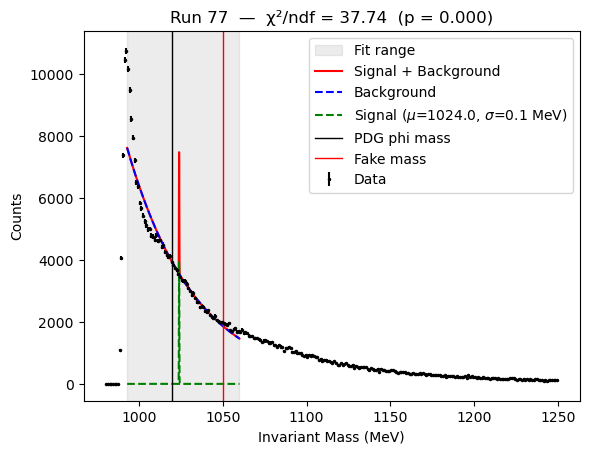

In [31]:

m_phi = 1019.461
m_lo, m_hi = fit_ranges[run_number]  # fit window in MeV
bin_width = 1            # MeV per bin

bins = np.arange(m_lo, m_hi + bin_width, bin_width)
counts, edges = np.histogram(df_cut.InvM, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])
errors = np.where(counts > 0, np.sqrt(counts), 1)  # Poisson errors, floor at 1

def signal(m, n_sig, mu, sigma):
    return n_sig / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((m - mu) / sigma) ** 2)

def background(m, n_bkg, lam):
    return n_bkg * lam * np.exp(-lam * (m - m_lo))

def model(m, n_sig, mu, sigma, n_bkg, lam):
    return signal(m, n_sig, mu, sigma) + background(m, n_bkg, lam)

p0     = [1000,  m_phi, 5,   counts.sum(), 1/30]
bounds = ([0,    1000,  0.1, 0,            0   ],
          [np.inf, 1060, 50, np.inf,       1   ])

popt, pcov = curve_fit(model, centers, counts, p0=p0, sigma=errors,
                       absolute_sigma=True, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
n_sig, mu, sigma, n_bkg, lam = popt
n_sig_err, mu_err, sigma_err = perr[:3]

chi2 = np.sum(((counts - model(centers, *popt)) / errors) ** 2)
ndf  = len(counts) - len(popt)
from scipy.stats import chi2 as chi2_dist
pval = chi2_dist.sf(chi2, ndf)
print(f"Signal yield : {n_sig:.1f} ± {n_sig_err:.1f}")
print(f"Mean         : {mu:.3f} ± {mu_err:.3f} MeV")
print(f"Sigma        : {sigma:.3f} ± {sigma_err:.3f} MeV")
print(f"χ²/ndf       : {chi2:.1f} / {ndf} = {chi2/ndf:.2f}  (p = {pval:.3f})")

# Full-range histogram
full_bins = np.arange(980, 1251, bin_width)
full_counts, full_edges = np.histogram(df_cut.InvM, bins=full_bins)
full_centers = 0.5 * (full_edges[:-1] + full_edges[1:])
full_errors = np.where(full_counts > 0, np.sqrt(full_counts), 1)

m_fine = np.linspace(m_lo, m_hi, 1000)
fig, ax = plt.subplots()
ax.errorbar(full_centers, full_counts, yerr=full_errors, fmt='k.', ms=3, label='Data')
ax.axvspan(m_lo, m_hi, color='grey', alpha=0.15, label='Fit range')
ax.plot(m_fine, model(m_fine, *popt),             'r-',  label='Signal + Background')
ax.plot(m_fine, background(m_fine, n_bkg, lam),   'b--', label='Background')
ax.plot(m_fine, signal(m_fine, n_sig, mu, sigma),  'g--', label=f'Signal ($\\mu$={mu:.1f}, $\\sigma$={sigma:.1f} MeV)')
ax.axvline(m_phi, color='k', linewidth=1, label='PDG phi mass')
ax.axvline(1050.0, color='r', linewidth=1, label='Fake mass')
ax.set_title(f'Run {run_number}  —  χ²/ndf = {chi2/ndf:.2f}  (p = {pval:.3f})')
ax.set_xlabel('Invariant Mass (MeV)')
ax.set_ylabel('Counts')
ax.legend()
plt.show()

In [32]:
plot_dir = '/Users/mghrear/Desktop/Ensemble_study/original/fitted_plots/'

results = []  # will hold dicts with run_number, mu, mu_err, sigma, sigma_err

for run_number, (m_lo, m_hi) in fit_ranges.items():

    # Load data and apply cuts
    df = pd.read_pickle(data_dir + f'ANN_ensemble_run{run_number}_selected.pk')
    df = df.loc[df.pos_E_Ecal > 0.6]
    df.InvM = df.InvM * 1000
    df_cut = df.nlargest(num, 'ANN_pred')

    # Histogram in fit window
    bins = np.arange(m_lo, m_hi + bin_width, bin_width)
    counts, edges = np.histogram(df_cut.InvM, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    errors = np.where(counts > 0, np.sqrt(counts), 1)

    try:
        popt, pcov = curve_fit(model, centers, counts, p0=p0, sigma=errors,
                               absolute_sigma=True, bounds=bounds)
        perr = np.sqrt(np.diag(pcov))
        n_sig, mu, sigma, n_bkg, lam = popt
        n_sig_err, mu_err, sigma_err = perr[:3]
        chi2 = np.sum(((counts - model(centers, *popt)) / errors) ** 2)
        ndf  = len(counts) - len(popt)
        from scipy.stats import chi2 as chi2_dist
        pval = chi2_dist.sf(chi2, ndf)
    except Exception as e:
        print(f'Run {run_number}: fit failed — {e}')
        continue

    print(f'Run {run_number:3d} | yield={n_sig:.0f}±{n_sig_err:.0f}  mu={mu:.2f}±{mu_err:.2f}  sigma={sigma:.2f}±{sigma_err:.2f} MeV  χ²/ndf={chi2/ndf:.2f}  p={pval:.3f}')
    results.append(dict(run=run_number, n_sig=n_sig, n_sig_err=n_sig_err, mu=mu, mu_err=mu_err, sigma=sigma, sigma_err=sigma_err, chi2_ndf=chi2/ndf, pval=pval))

    # Full-range histogram for plot
    full_bins = np.arange(980, 1251, bin_width)
    full_counts, full_edges = np.histogram(df_cut.InvM, bins=full_bins)
    full_centers = 0.5 * (full_edges[:-1] + full_edges[1:])
    full_errors = np.where(full_counts > 0, np.sqrt(full_counts), 1)

    m_fine = np.linspace(m_lo, m_hi, 1000)
    fig, ax = plt.subplots()
    ax.errorbar(full_centers, full_counts, yerr=full_errors, fmt='k.', ms=3, label='Data')
    ax.axvspan(m_lo, m_hi, color='grey', alpha=0.15, label='Fit range')
    ax.plot(m_fine, model(m_fine, *popt),            'r-',  label='Signal + Background')
    ax.plot(m_fine, background(m_fine, n_bkg, lam),  'b--', label='Background')
    ax.plot(m_fine, signal(m_fine, n_sig, mu, sigma), 'g--', label=f'Signal ($\\mu$={mu:.1f}, $\\sigma$={sigma:.1f} MeV)')
    ax.axvline(m_phi, color='k', linewidth=1, label='PDG phi mass')
    ax.axvline(1050.0, color='r', linewidth=1, label='Fake mass')
    ax.set_title(f'Run {run_number}  —  χ²/ndf = {chi2/ndf:.2f}  (p = {pval:.3f})')
    ax.set_xlabel('Invariant Mass (MeV)')
    ax.set_ylabel('Counts')
    ax.legend()
    fig.savefig(plot_dir + f'run{run_number}.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

results = pd.DataFrame(results).set_index('run').sort_index()
print('\nDone.')
print(results)


Run  14 | yield=0±0  mu=1000.58±0.00  sigma=0.12±0.00 MeV  χ²/ndf=9.47  p=0.000
Run  26 | yield=6140±594  mu=1025.55±0.33  sigma=5.00±0.39 MeV  χ²/ndf=1.18  p=0.226
Run  28 | yield=98±139  mu=1022.13±0.95  sigma=0.62±1.45 MeV  χ²/ndf=35.07  p=0.000
Run  36 | yield=11241±757  mu=1024.58±0.26  sigma=5.95±0.32 MeV  χ²/ndf=1.16  p=0.237
Run  37 | yield=93±0  mu=1059.70±0.00  sigma=0.65±0.00 MeV  χ²/ndf=23.58  p=0.000
Run  39 | yield=22321±1482  mu=1021.46±0.24  sigma=7.06±0.31 MeV  χ²/ndf=3.21  p=0.000
Run  40 | yield=4954±559  mu=1024.34±0.42  sigma=5.15±0.50 MeV  χ²/ndf=1.14  p=0.266
Run  41 | yield=10374±569  mu=1023.86±0.21  sigma=5.26±0.25 MeV  χ²/ndf=1.89  p=0.001
Run  43 | yield=9091±1224  mu=1022.10±0.55  sigma=7.88±0.75 MeV  χ²/ndf=1.46  p=0.029
Run  45 | yield=23384±1984  mu=1022.12±0.32  sigma=9.11±0.49 MeV  χ²/ndf=1.01  p=0.461
Run  46 | yield=10186±880  mu=1022.14±0.34  sigma=6.18±0.41 MeV  χ²/ndf=1.25  p=0.144
Run  51 | yield=4799±490  mu=1025.37±0.37  sigma=5.15±0.44 MeV  χ²

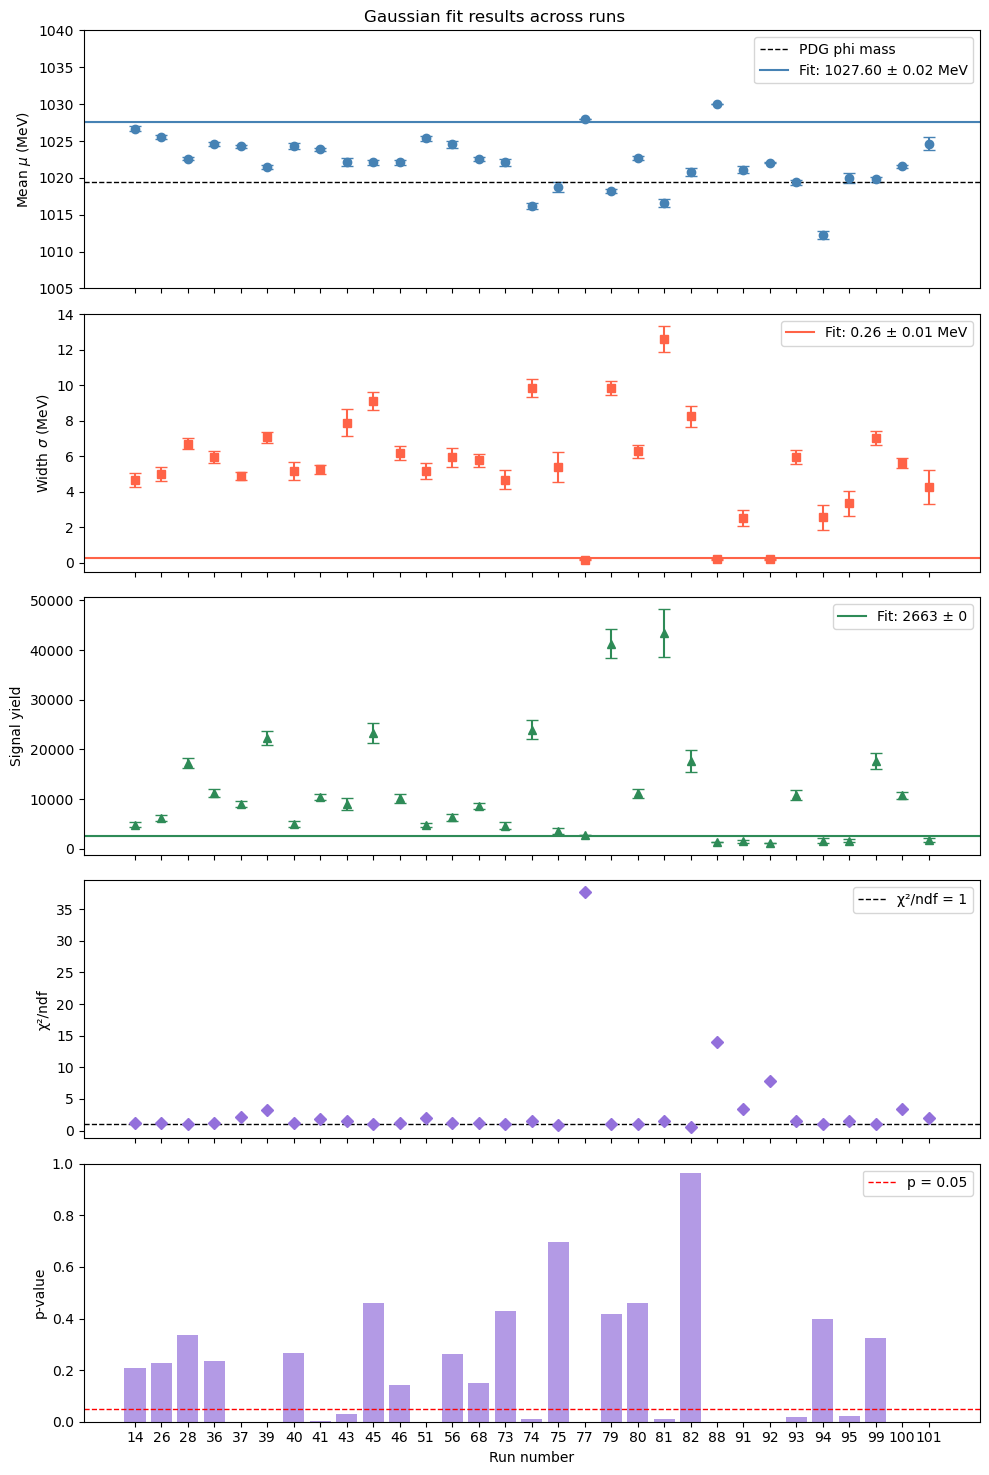

In [157]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 15), sharex=True)

runs = results.index.to_numpy()
x = np.arange(len(runs))

# Weighted mean fits
w_mu = 1 / results.mu_err**2
mu_fit = (w_mu * results.mu).sum() / w_mu.sum()
mu_fit_err = 1 / np.sqrt(w_mu.sum())

w_sig = 1 / results.sigma_err**2
sigma_fit = (w_sig * results.sigma).sum() / w_sig.sum()
sigma_fit_err = 1 / np.sqrt(w_sig.sum())

w_nsig = 1 / results.n_sig_err**2
nsig_fit = (w_nsig * results.n_sig).sum() / w_nsig.sum()
nsig_fit_err = 1 / np.sqrt(w_nsig.sum())

ax1.errorbar(x, results.mu, yerr=results.mu_err, fmt='o', color='steelblue', capsize=4)
ax1.axhline(m_phi, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
ax1.axhline(mu_fit, color='steelblue', linestyle='-', linewidth=1.5, label=f'Fit: {mu_fit:.2f} ± {mu_fit_err:.2f} MeV')
ax1.axhspan(mu_fit - mu_fit_err, mu_fit + mu_fit_err, color='steelblue', alpha=0.15)
ax1.set_ylabel('Mean $\\mu$ (MeV)')
ax1.set_ylim(1005, 1040)
ax1.legend()

ax2.errorbar(x, results.sigma, yerr=results.sigma_err, fmt='s', color='tomato', capsize=4)
ax2.axhline(sigma_fit, color='tomato', linestyle='-', linewidth=1.5, label=f'Fit: {sigma_fit:.2f} ± {sigma_fit_err:.2f} MeV')
ax2.axhspan(sigma_fit - sigma_fit_err, sigma_fit + sigma_fit_err, color='tomato', alpha=0.15)
ax2.set_ylabel('Width $\\sigma$ (MeV)')
ax2.legend()

ax3.errorbar(x, results.n_sig, yerr=results.n_sig_err, fmt='^', color='seagreen', capsize=4)
ax3.axhline(nsig_fit, color='seagreen', linestyle='-', linewidth=1.5, label=f'Fit: {nsig_fit:.0f} ± {nsig_fit_err:.0f}')
ax3.axhspan(nsig_fit - nsig_fit_err, nsig_fit + nsig_fit_err, color='seagreen', alpha=0.15)
ax3.set_ylabel('Signal yield')
ax3.legend()

ax4.errorbar(x, results.chi2_ndf, fmt='D', color='mediumpurple', capsize=4)
ax4.axhline(1.0, color='k', linestyle='dashed', linewidth=1, label='χ²/ndf = 1')
ax4.set_ylabel('χ²/ndf')
ax4.legend()

ax5.bar(x, results.pval, color='mediumpurple', alpha=0.7)
ax5.axhline(0.05, color='r', linestyle='dashed', linewidth=1, label='p = 0.05')
ax5.set_ylabel('p-value')
ax5.set_ylim(0, 1)
ax5.legend()

ax5.set_xticks(x)
ax5.set_xticklabels(runs)
ax5.set_xlabel('Run number')

fig.suptitle('Gaussian fit results across runs')
fig.tight_layout()
fig.savefig(plot_dir + 'summary.png', dpi=150, bbox_inches='tight')
plt.show()


16 / 31 runs pass p > 0.05

            n_sig    n_sig_err           mu    mu_err     sigma  sigma_err  chi2_ndf      pval
run                                                                                           
14    4872.642227   500.356108  1026.635639  0.338995  4.653583   0.399576  1.200668  0.207422
26    6139.943728   594.262232  1025.554603  0.327974  5.001153   0.391323  1.181994  0.226294
28   17343.485921  1029.175050  1022.629487  0.236156  6.704586   0.293901  1.083658  0.337277
36   11240.718934   756.529013  1024.580809  0.259359  5.950327   0.320146  1.160521  0.236568
40    4953.959199   558.838341  1024.337433  0.422186  5.151752   0.495180  1.135951  0.266397
45   23384.064357  1984.393076  1022.116427  0.320484  9.113864   0.493367  1.005506  0.460503
46   10186.168654   880.063274  1022.143071  0.341643  6.176055   0.409157  1.254707  0.143501
56    6319.978571   703.527256  1024.541248  0.422998  5.940082   0.524947  1.137854  0.264005
68    8592.838328   59

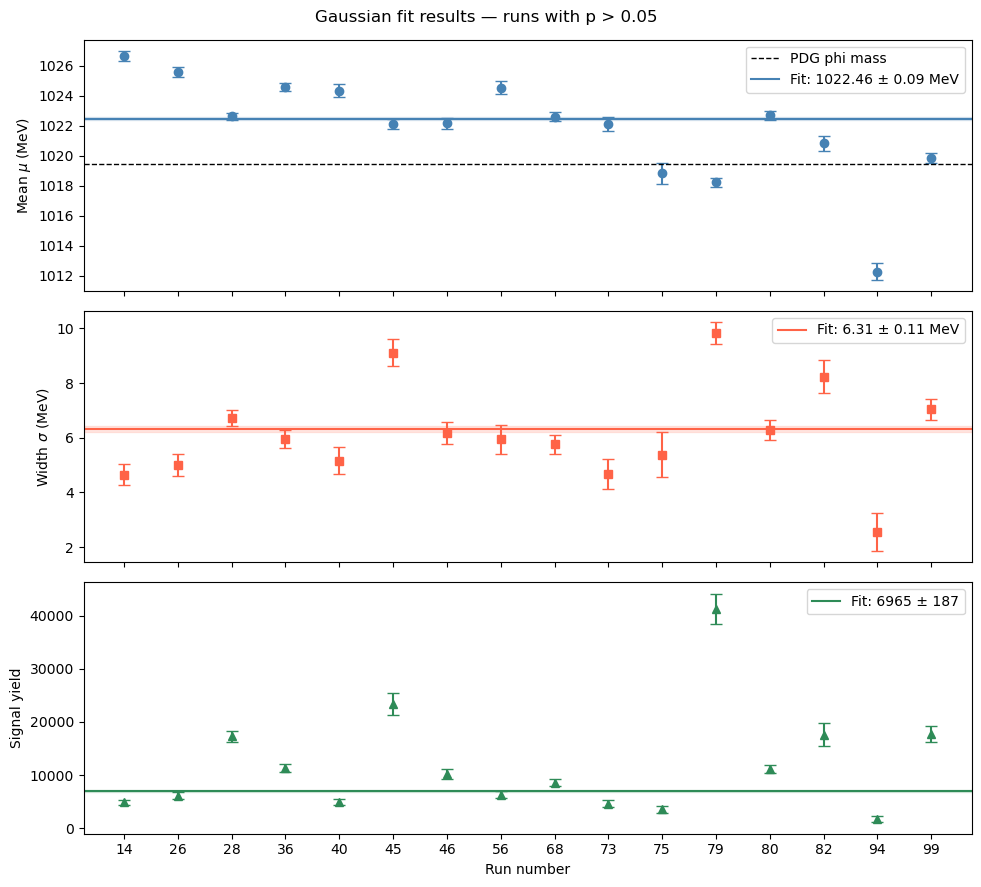

In [158]:
pval_cut = 0.05
good = results[results.pval > pval_cut].copy()
print(f'{len(good)} / {len(results)} runs pass p > {pval_cut}\n')
print(good[['n_sig','n_sig_err','mu','mu_err','sigma','sigma_err','chi2_ndf','pval']].to_string())

runs_good = good.index.to_numpy()
x = np.arange(len(runs_good))

w_mu = 1 / good.mu_err**2
mu_fit = (w_mu * good.mu).sum() / w_mu.sum()
mu_fit_err = 1 / np.sqrt(w_mu.sum())

w_sig = 1 / good.sigma_err**2
sigma_fit = (w_sig * good.sigma).sum() / w_sig.sum()
sigma_fit_err = 1 / np.sqrt(w_sig.sum())

w_nsig = 1 / good.n_sig_err**2
nsig_fit = (w_nsig * good.n_sig).sum() / w_nsig.sum()
nsig_fit_err = 1 / np.sqrt(w_nsig.sum())

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

ax1.errorbar(x, good.mu, yerr=good.mu_err, fmt='o', color='steelblue', capsize=4)
ax1.axhline(m_phi, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
ax1.axhline(mu_fit, color='steelblue', linestyle='-', linewidth=1.5, label=f'Fit: {mu_fit:.2f} ± {mu_fit_err:.2f} MeV')
ax1.axhspan(mu_fit - mu_fit_err, mu_fit + mu_fit_err, color='steelblue', alpha=0.15)
ax1.set_ylabel('Mean $\\mu$ (MeV)')
ax1.legend()

ax2.errorbar(x, good.sigma, yerr=good.sigma_err, fmt='s', color='tomato', capsize=4)
ax2.axhline(sigma_fit, color='tomato', linestyle='-', linewidth=1.5, label=f'Fit: {sigma_fit:.2f} ± {sigma_fit_err:.2f} MeV')
ax2.axhspan(sigma_fit - sigma_fit_err, sigma_fit + sigma_fit_err, color='tomato', alpha=0.15)
ax2.set_ylabel('Width $\\sigma$ (MeV)')
ax2.legend()

ax3.errorbar(x, good.n_sig, yerr=good.n_sig_err, fmt='^', color='seagreen', capsize=4)
ax3.axhline(nsig_fit, color='seagreen', linestyle='-', linewidth=1.5, label=f'Fit: {nsig_fit:.0f} ± {nsig_fit_err:.0f}')
ax3.axhspan(nsig_fit - nsig_fit_err, nsig_fit + nsig_fit_err, color='seagreen', alpha=0.15)
ax3.set_ylabel('Signal yield')
ax3.legend()

ax3.set_xticks(x)
ax3.set_xticklabels(runs_good)
ax3.set_xlabel('Run number')

fig.suptitle(f'Gaussian fit results — runs with p > {pval_cut}')
fig.tight_layout()
fig.savefig(plot_dir + 'summary_good.png', dpi=150, bbox_inches='tight')
plt.show()
